In [12]:
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langgraph.graph import StateGraph,START, END
from typing import TypedDict
from IPython.display import Image
import os

In [13]:
os.environ['HF_HOME'] = r'D:\huggingface_cache\chat_models\Qwen3-0.6B'

llm = HuggingFacePipeline.from_model_id(
    model_id='Qwen/Qwen3-0.6B',
    task='text-generation'
)

model = ChatHuggingFace(llm=llm)

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 3820.68it/s]


In [14]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [15]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f'Please create the outline of the following title - {title}'
    outline = model.invoke(prompt)
    state['outline'] = outline
    return state

In [16]:
def create_contnet(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Please create the detailed content of the following title - {title} and outline - {outline}'
    outline = model.invoke(prompt)
    state['outline'] = outline
    return state

In [18]:
# create our graph
graph = StateGraph(BlogState)
# add nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_contnet', create_contnet)
# add edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_contnet')
graph.add_edge('create_contnet', END)
# compile
workflow = graph.compile()

In [19]:
# execute

intial_state = {'title': 'The Rise of AI in Pakistan'}

final_state = workflow.invoke(intial_state)

print(final_state)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'title': 'The Rise of AI in Pakistan', 'outline': AIMessage(content='<|im_start|>user\nPlease create the detailed content of the following title - The Rise of AI in Pakistan and outline - content=\'<|im_start|>user\\nPlease create the outline of the following title - The Rise of AI in Pakistan<|im_end|>\\n<|im_start|>assistant\\n<think>\\nOkay, the user wants the outline for the title "The Rise of AI in Pakistan." Let me start by breaking down the title. "Rise of AI" suggests a growing trend or development in AI in Pakistan. The key elements here are Pakistan, AI, and the growth.\\n\\nFirst, I need to structure the title into parts. The title is typically divided into a main subject and a specific focus. So, the main subject would be AI, and the focus is Pakistan\\\'s rise. Maybe include some keywords like Pakistan, AI, and growth.\\n\\nNext, I should consider what the outline would look like. Perhaps start with an introduction about the current state of AI in Pakistan. Then delve int

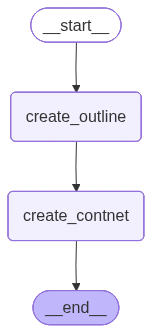

In [20]:
Image(workflow.get_graph().draw_mermaid_png())